In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv('D:\FLIGHT PRICE PREDICTOR\BASE\clean_flight_dataset1.csv')

In [10]:
df.shape

(4916353, 18)

In [11]:
df.head(50)

,MONTH,DAY,DAY_OF_WEEK,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_TIME,DISTANCE,FARE,AIRLINE,DEP_HOUR,ARR_HOUR,DEP_MIN,ARR_MIN,IS_WEEKEND,ROUTE,DEP_TIME_BIN,IS_HOLIDAY_SEASON,FARE_PER_MILE
0,1,1,4,ANC,SEA,205.0,1448,266.42,Alaska Airlines Inc.,0,4,5,30,0,ANC_SEA,Early_Morning,0,0.183992
1,1,1,4,SEA,ANC,235.0,1448,267.21,Alaska Airlines Inc.,0,3,25,20,0,SEA_ANC,Early_Morning,0,0.184537
2,1,1,4,SFO,MSP,217.0,1589,288.16,Delta Air Lines Inc.,0,6,25,2,0,SFO_MSP,Early_Morning,0,0.181347
3,1,1,4,LAS,MSP,181.0,1299,247.22,Spirit Air Lines,0,5,25,26,0,LAS_MSP,Early_Morning,0,0.190316
4,1,1,4,SFO,DFW,195.0,1464,269.36,American Airlines Inc.,0,5,30,45,0,SFO_DFW,Early_Morning,0,0.183989
5,1,1,4,LAS,ATL,221.0,1747,312.09,Delta Air Lines Inc.,0,7,30,11,0,LAS_ATL,Early_Morning,0,0.178643
6,1,1,4,DEN,ATL,173.0,1199,229.87,Delta Air Lines Inc.,0,5,30,23,0,DEN_ATL,Early_Morning,0,0.191718
7,1,1,4,LAX,MSP,214.0,1535,280.16,Delta Air Lines Inc.,0,6,35,9,0,LAX_MSP,Early_Morning,0,0.182515
8,1,1,4,SLC,ATL,215.0,1590,287.96,Delta Air Lines Inc.,0,6,40,15,0,SLC_ATL,Early_Morning,0,0.181107
9,1,1,4,SEA,MSP,189.0,1399,259.75,Delta Air Lines Inc.,0,5,40,49,0,SEA_MSP,Early_Morning,0,0.185668


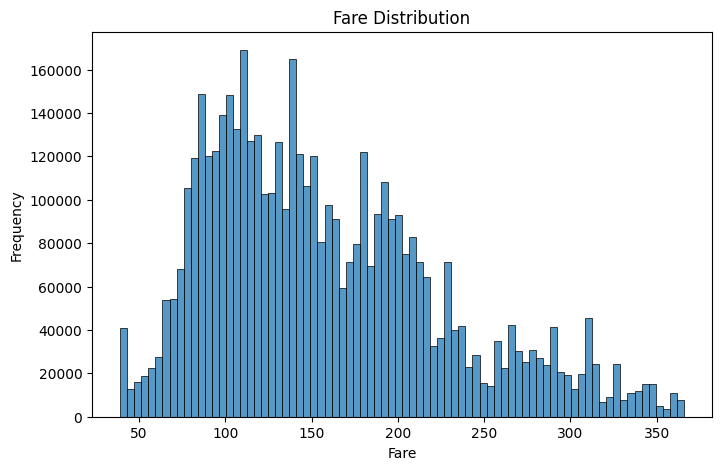

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["FARE"], bins=80, kde=False)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

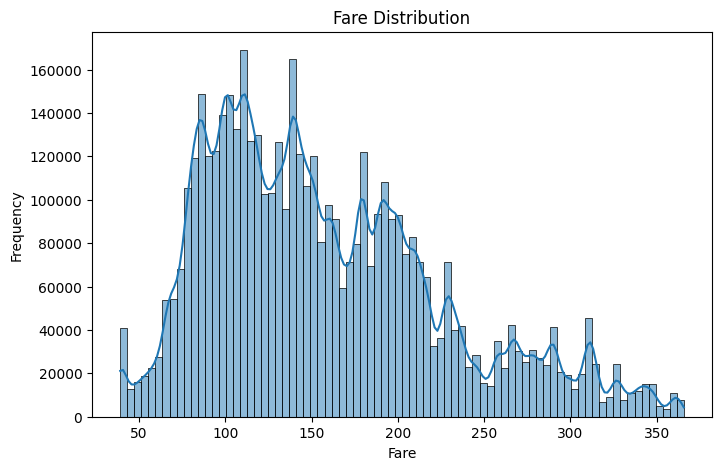

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["FARE"], bins=80, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

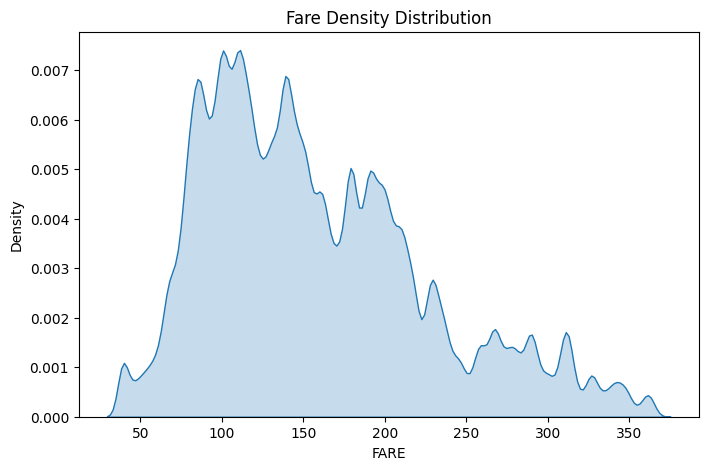

In [14]:
plt.figure(figsize=(8,5))
sns.kdeplot(df["FARE"], fill=True)
plt.title("Fare Density Distribution")
plt.show()

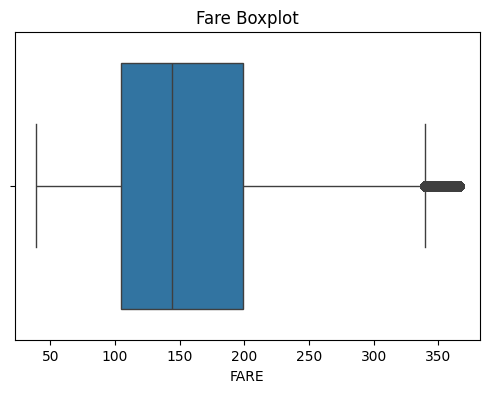

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["FARE"])
plt.title("Fare Boxplot")
plt.show()

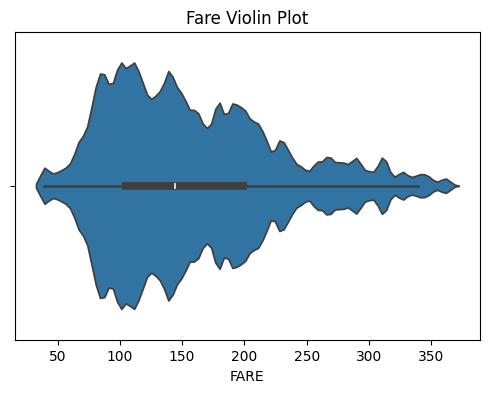

In [16]:
plt.figure(figsize=(6,4))
sns.violinplot(x=df["FARE"])
plt.title("Fare Violin Plot")
plt.show()

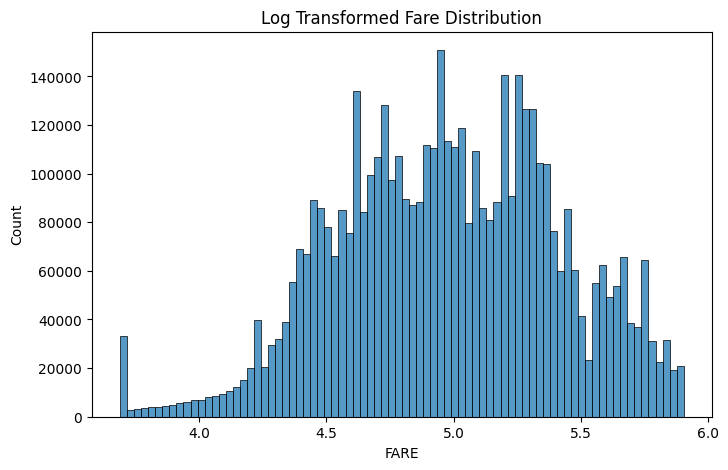

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df["FARE"]), bins=80)
plt.title("Log Transformed Fare Distribution")
plt.show()

In [18]:
print("Skewness:", df["FARE"].skew())
print("Kurtosis:", df["FARE"].kurtosis())

Skewness: 0.7734565597031714
Kurtosis: 0.04378595610653857


In [19]:
print(df["FARE"].quantile([0.10,0.25,0.50,0.75,0.90,0.95,0.99]))

0.10     82.61
0.25    104.79
0.50    144.30
0.75    198.65
0.90    263.48
0.95    298.09
0.99    342.48
Name: FARE, dtype: float64


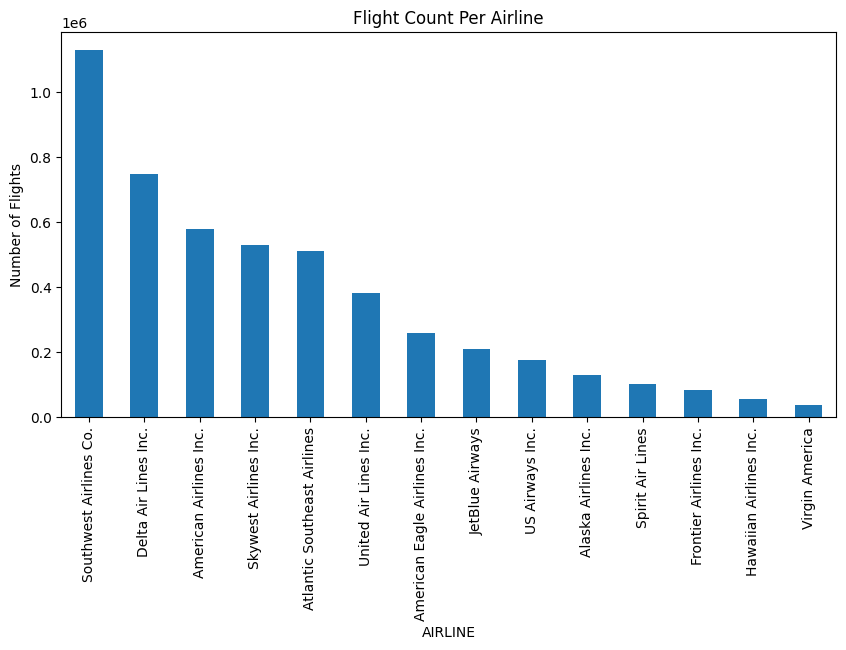

In [20]:
plt.figure(figsize=(10,5))
df["AIRLINE"].value_counts().plot(kind="bar")
plt.title("Flight Count Per Airline")
plt.ylabel("Number of Flights")
plt.show()

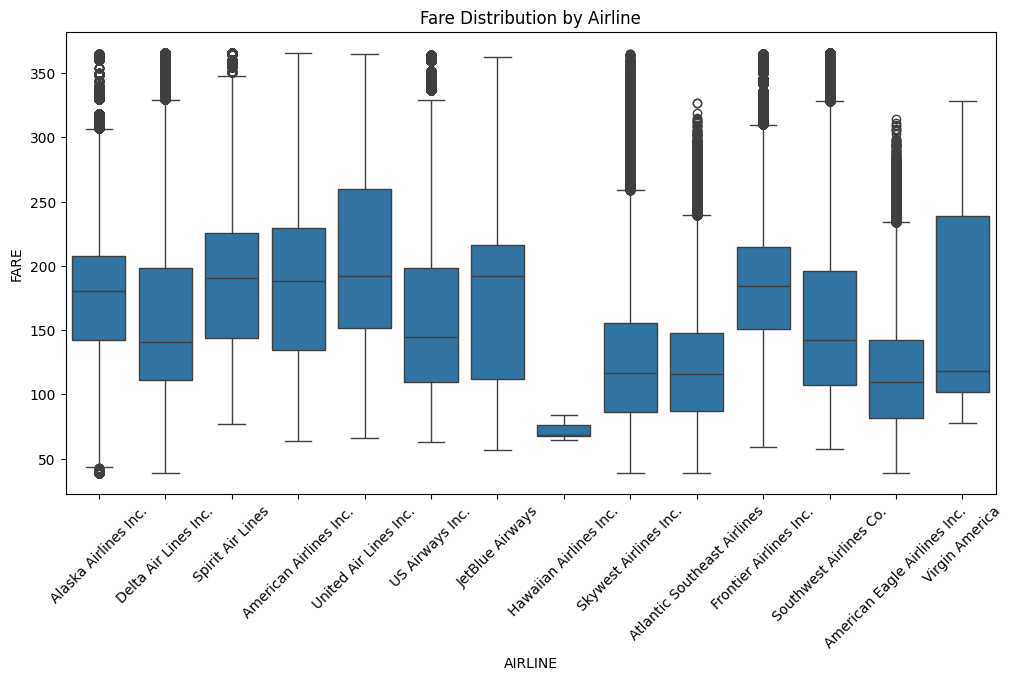

In [21]:
plt.figure(figsize=(12,6))
sns.boxplot(x="AIRLINE", y="FARE", data=df)
plt.xticks(rotation=45)
plt.title("Fare Distribution by Airline")
plt.show()

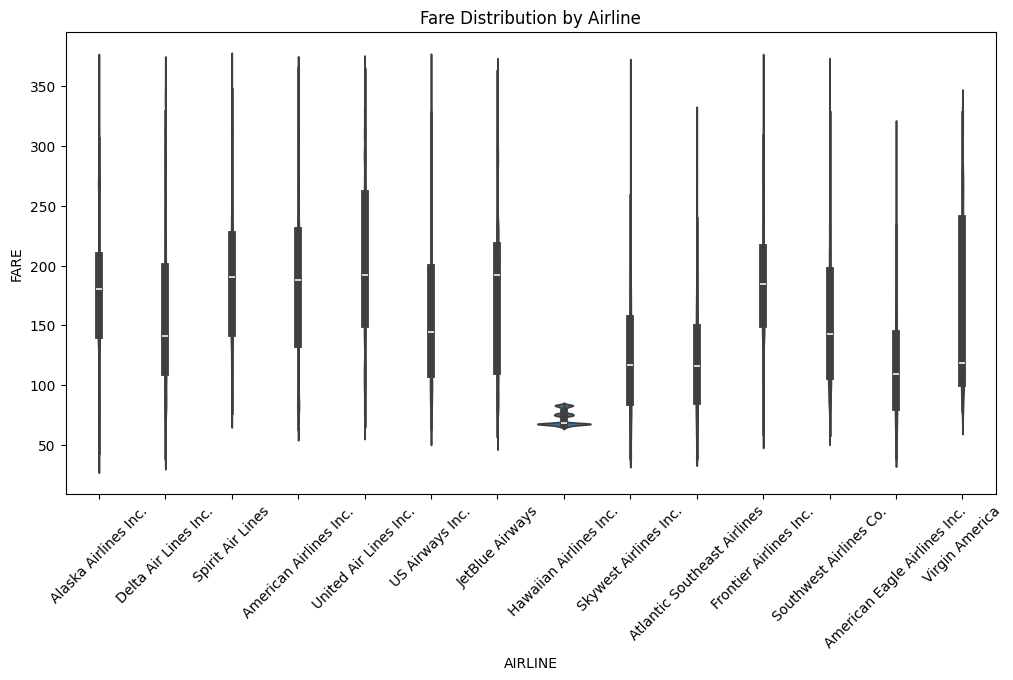

In [22]:
plt.figure(figsize=(12,6))
sns.violinplot(x="AIRLINE", y="FARE", data=df)
plt.xticks(rotation=45)
plt.title("Fare Distribution by Airline")
plt.show()

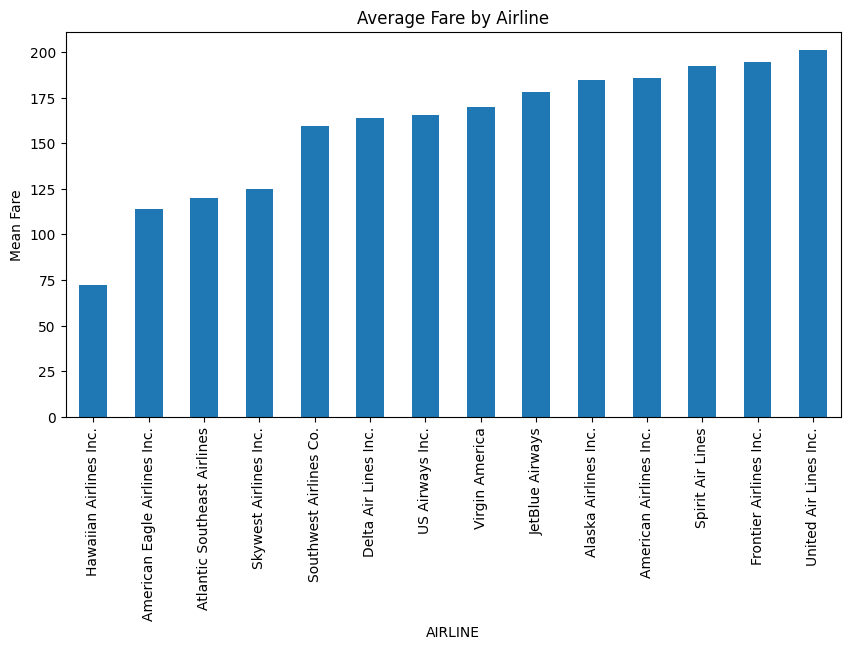

In [23]:
mean_fare = df.groupby("AIRLINE")["FARE"].mean().sort_values()

mean_fare.plot(kind="bar", figsize=(10,5))
plt.title("Average Fare by Airline")
plt.ylabel("Mean Fare")
plt.show()

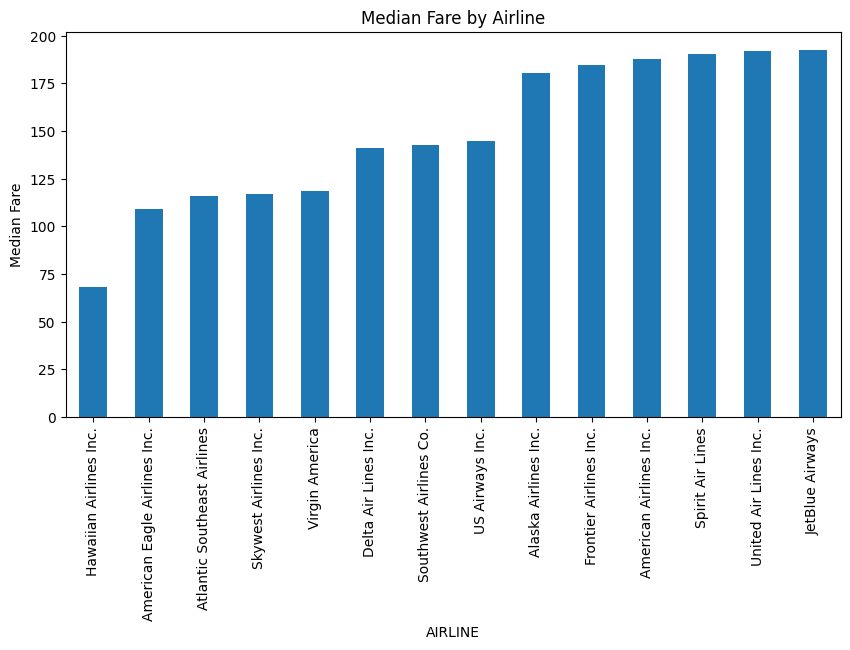

In [24]:
median_fare = df.groupby("AIRLINE")["FARE"].median().sort_values()

median_fare.plot(kind="bar", figsize=(10,5))
plt.title("Median Fare by Airline")
plt.ylabel("Median Fare")
plt.show()

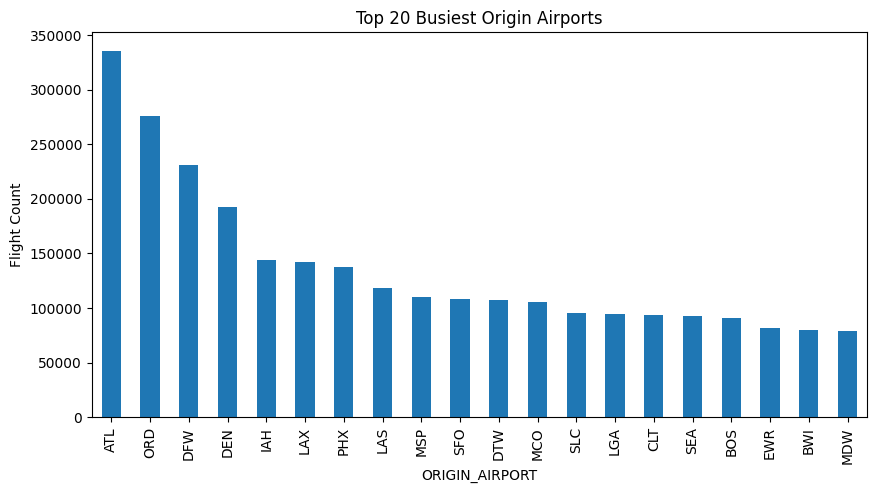

In [25]:
top_airports = df["ORIGIN_AIRPORT"].value_counts().head(20)

top_airports.plot(kind="bar", figsize=(10,5))
plt.title("Top 20 Busiest Origin Airports")
plt.ylabel("Flight Count")
plt.show()

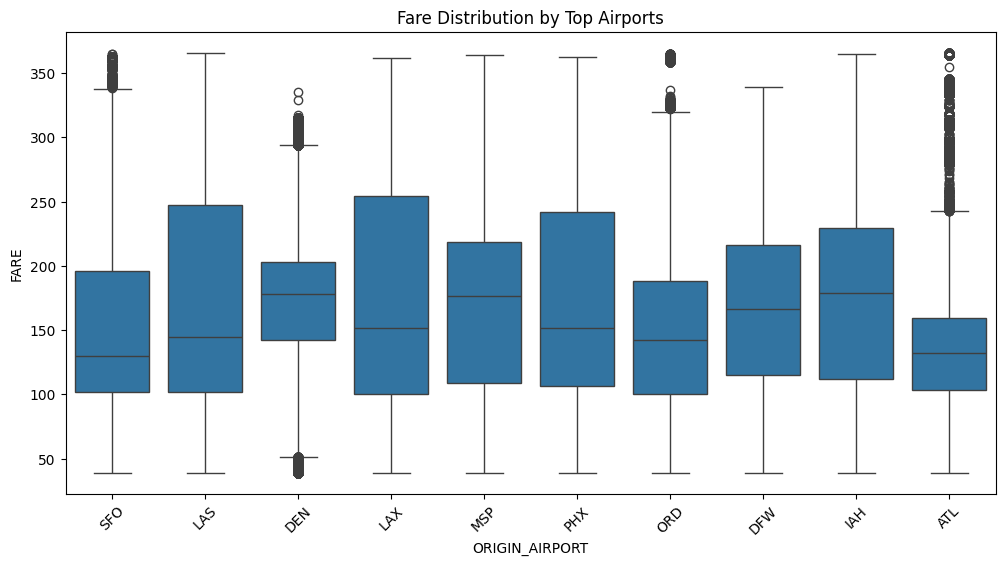

In [26]:
top10 = df["ORIGIN_AIRPORT"].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.boxplot(x="ORIGIN_AIRPORT", y="FARE", data=df[df["ORIGIN_AIRPORT"].isin(top10)])
plt.xticks(rotation=45)
plt.title("Fare Distribution by Top Airports")
plt.show()

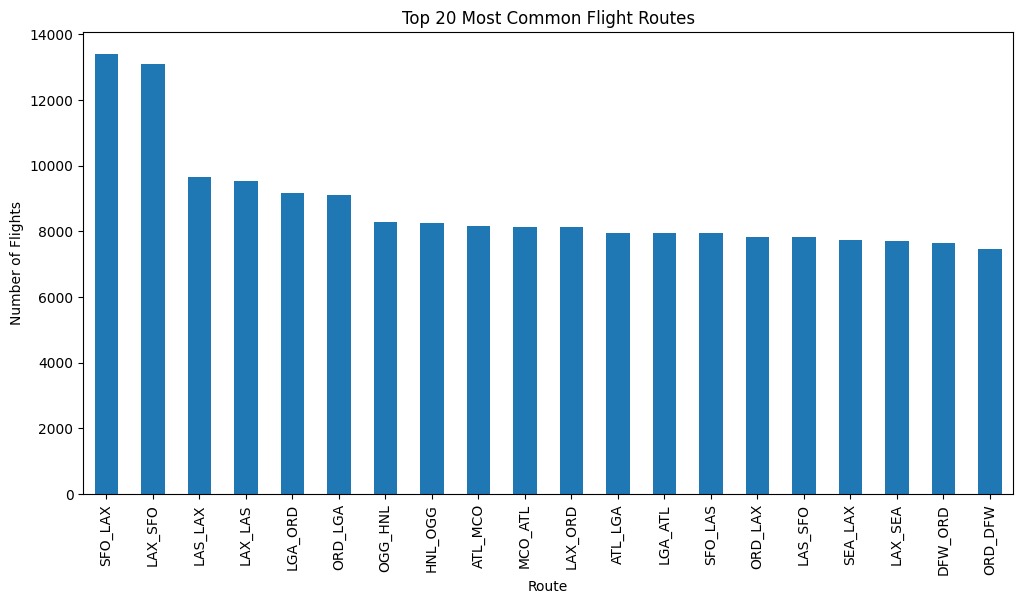

In [27]:
common = df['ROUTE'].value_counts().head(20)
common.plot(kind='bar', figsize=(12,6))
plt.title('Top 20 Most Common Flight Routes')
plt.xlabel('Route')
plt.ylabel('Number of Flights')
plt.show()

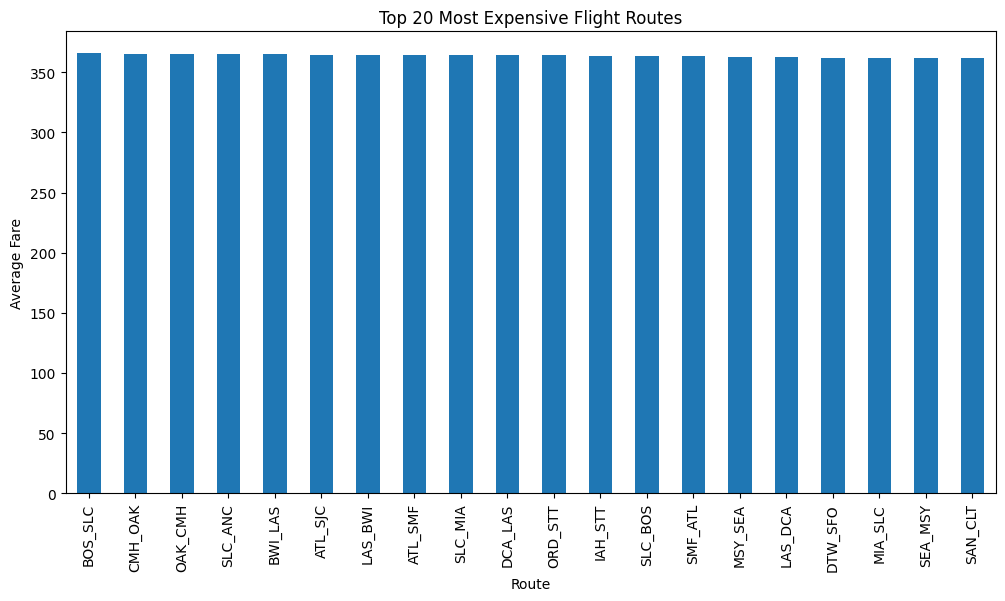

In [28]:
expensive_routes = df.groupby('ROUTE')['FARE'].mean().sort_values(ascending=False).head(20)
expensive_routes.plot(kind='bar', figsize=(12,6))
plt.title('Top 20 Most Expensive Flight Routes')
plt.xlabel('Route')
plt.ylabel('Average Fare')
plt.show()


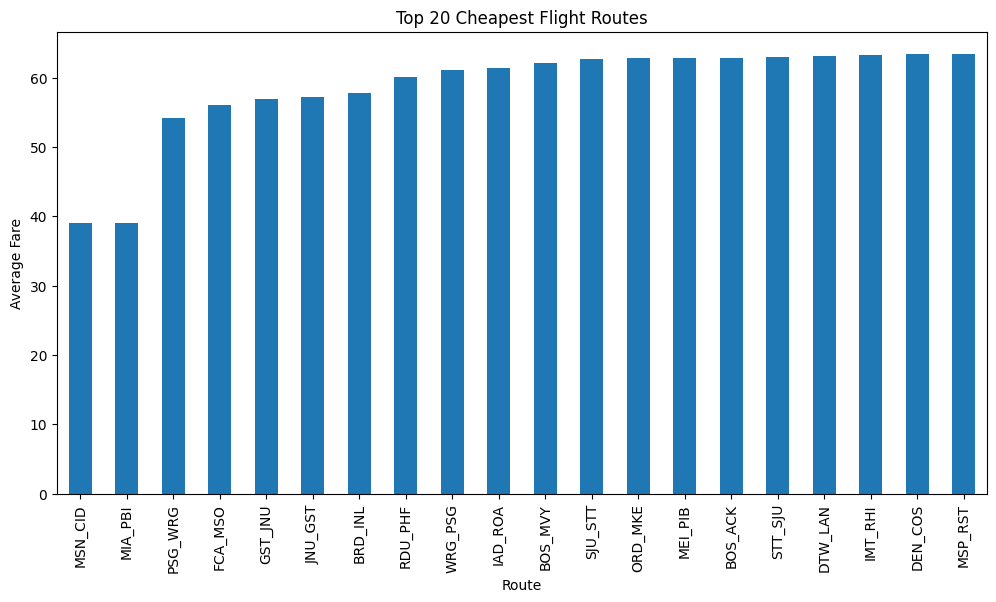

In [29]:
cheap_routes = df.groupby('ROUTE')['FARE'].mean().sort_values(ascending=True).head(20)
cheap_routes.plot(kind='bar', figsize=(12,6))
plt.title('Top 20 Cheapest Flight Routes')
plt.xlabel('Route')
plt.ylabel('Average Fare')
plt.show()

In [30]:
df.head()

,MONTH,DAY,DAY_OF_WEEK,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_TIME,DISTANCE,FARE,AIRLINE,DEP_HOUR,ARR_HOUR,DEP_MIN,ARR_MIN,IS_WEEKEND,ROUTE,DEP_TIME_BIN,IS_HOLIDAY_SEASON,FARE_PER_MILE
0,1,1,4,ANC,SEA,205.0,1448,266.42,Alaska Airlines Inc.,0,4,5,30,0,ANC_SEA,Early_Morning,0,0.183992
1,1,1,4,SEA,ANC,235.0,1448,267.21,Alaska Airlines Inc.,0,3,25,20,0,SEA_ANC,Early_Morning,0,0.184537
2,1,1,4,SFO,MSP,217.0,1589,288.16,Delta Air Lines Inc.,0,6,25,2,0,SFO_MSP,Early_Morning,0,0.181347
3,1,1,4,LAS,MSP,181.0,1299,247.22,Spirit Air Lines,0,5,25,26,0,LAS_MSP,Early_Morning,0,0.190316
4,1,1,4,SFO,DFW,195.0,1464,269.36,American Airlines Inc.,0,5,30,45,0,SFO_DFW,Early_Morning,0,0.183989


TEMPORAL ANALYSIS


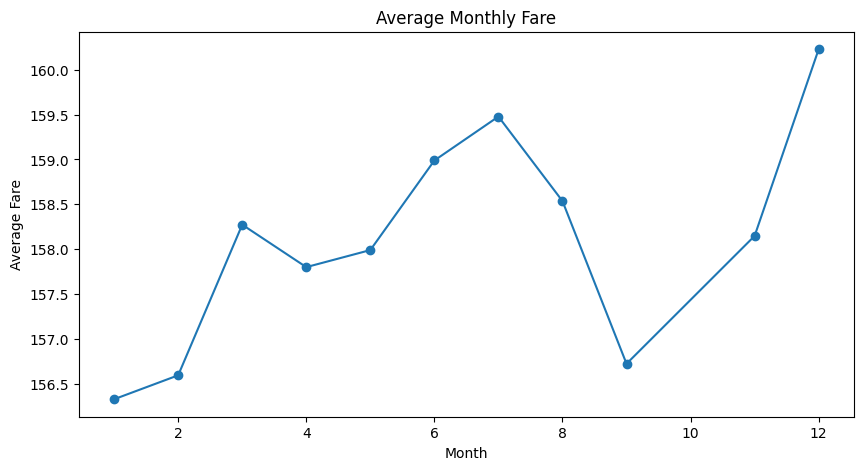

In [31]:
avg_monthly_fare = df.groupby('MONTH')['FARE'].mean()
avg_monthly_fare.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Average Monthly Fare')
plt.xlabel('Month')
plt.ylabel('Average Fare')
plt.show()

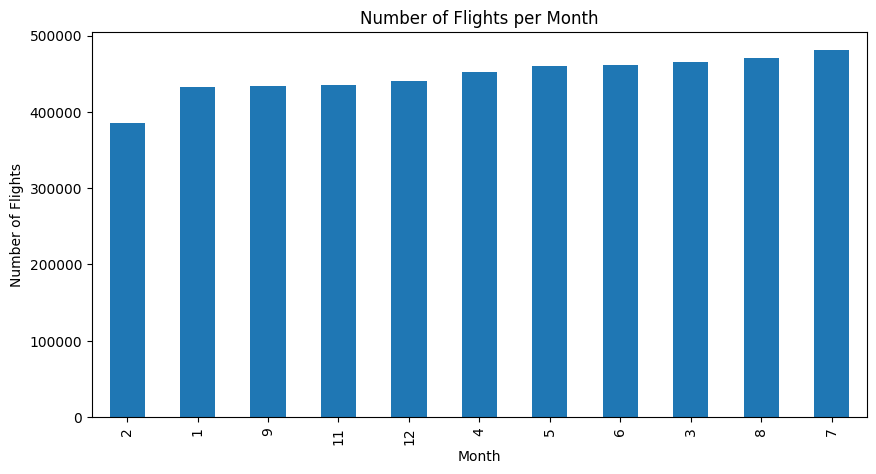

In [32]:
flight_counts = df['MONTH'].value_counts().sort_index().sort_values()
flight_counts.plot(kind='bar', figsize=(10,5))
plt.title('Number of Flights per Month')
plt.xlabel('Month')
plt.ylabel('Number of Flights')
plt.show()

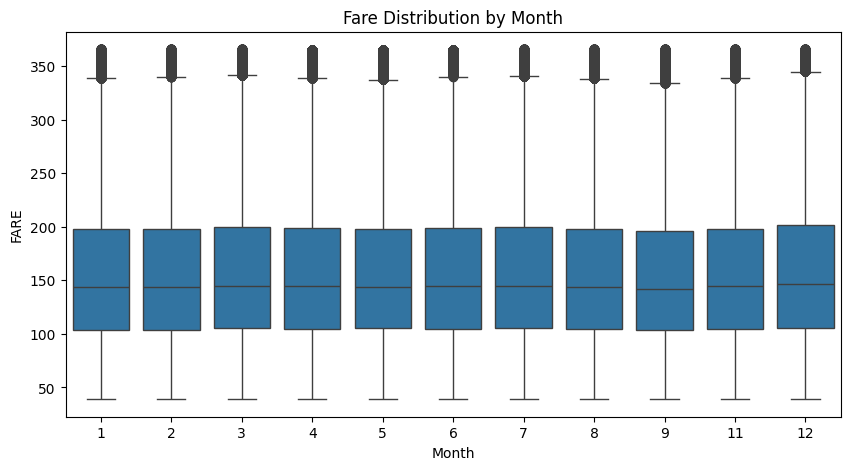

In [33]:
plt.figure(figsize=(10,5))
sns.boxplot(x='MONTH', y='FARE', data=df)
plt.title('Fare Distribution by Month')
plt.xlabel('Month')
plt.show()

DAY OF WEEK

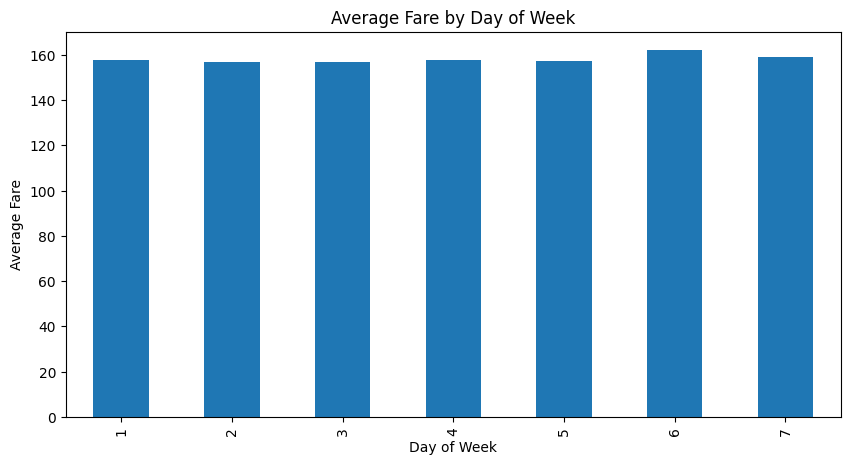

In [34]:
avg_fare_day_of_week = df.groupby('DAY_OF_WEEK')['FARE'].mean()
avg_fare_day_of_week.plot(kind = 'bar', figsize=(10,5))
plt.title('Average Fare by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Fare')
plt.show()

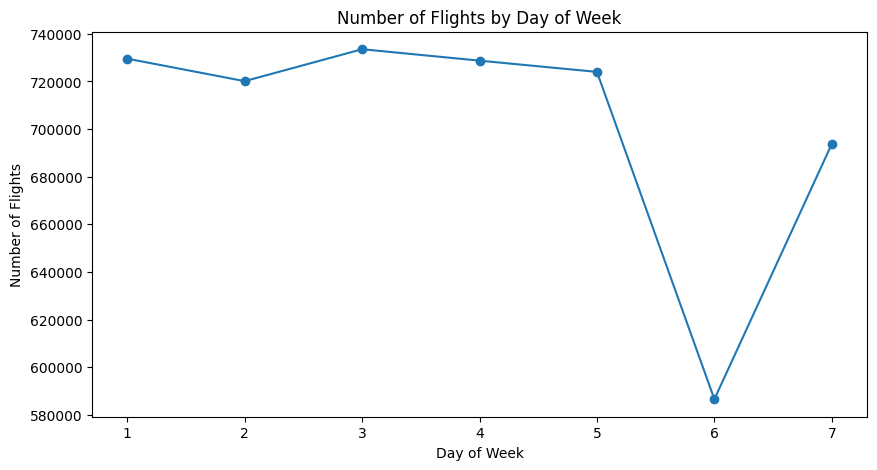

In [35]:
flight_count = df['DAY_OF_WEEK'].value_counts().sort_index()
flight_count.plot(kind = 'line', marker='o', figsize=(10,5))
plt.title('Number of Flights by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Flights')
plt.show()

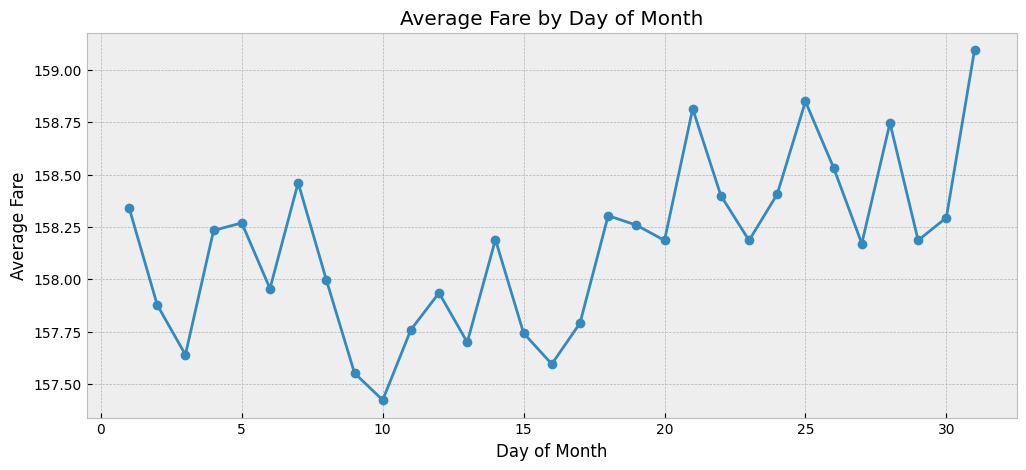

In [36]:
plt.style.use('bmh')

avg_fare_on_day_of_month = df.groupby('DAY')['FARE'].mean()
avg_fare_on_day_of_month.plot(kind='line', marker='o', figsize=(12,5))
plt.title('Average Fare by Day of Month')
plt.xlabel('Day of Month')
plt.ylabel('Average Fare')
plt.show()

In [37]:
plt.style.use('bmh')

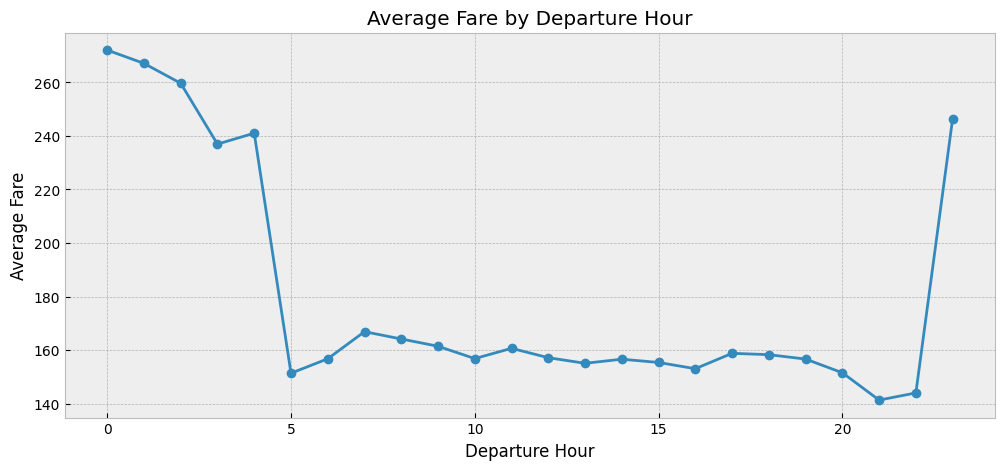

In [38]:
avg_fare_by_dep_hour = df.groupby('DEP_HOUR')['FARE'].mean()
avg_fare_by_dep_hour.plot(kind='line', marker='o', figsize=(12,5))
plt.title('Average Fare by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Average Fare')
plt.show()

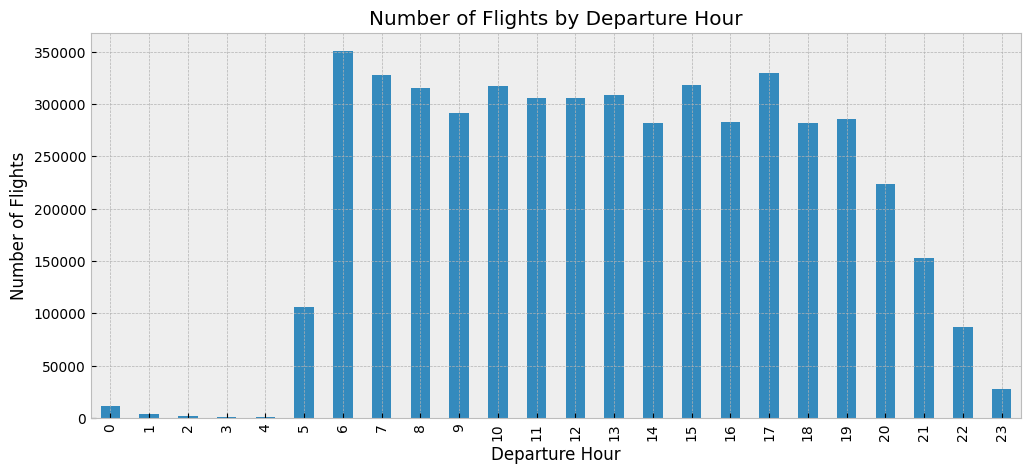

In [39]:
flight_counts_by_dep_hour = df['DEP_HOUR'].value_counts().sort_index()
flight_counts_by_dep_hour.plot(kind = 'bar', figsize=(12,5))
plt.title('Number of Flights by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Number of Flights')
plt.show()

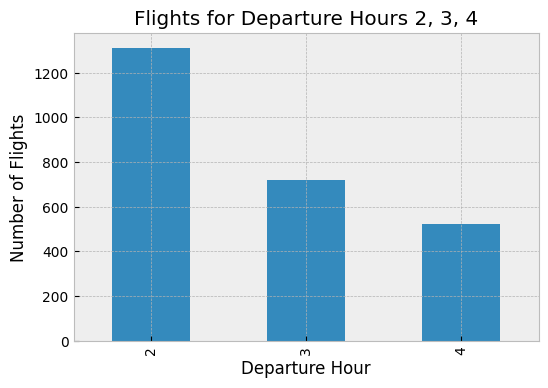

In [40]:
hours = [2, 3, 4]

flight_count = df[df['DEP_HOUR'].isin(hours)]['DEP_HOUR'].value_counts().sort_index()

flight_count.plot(kind='bar', figsize=(6,4))

plt.title('Flights for Departure Hours 2, 3, 4')
plt.xlabel('Departure Hour')
plt.ylabel('Number of Flights')
plt.show()

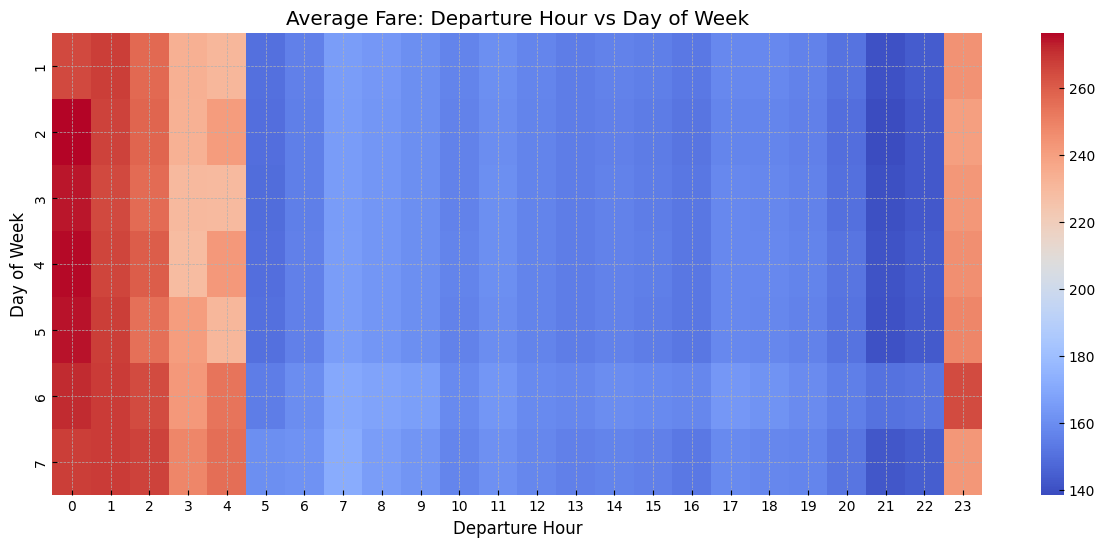

In [41]:
pivot = df.pivot_table(
    values="FARE",
    index="DAY_OF_WEEK",
    columns="DEP_HOUR",
    aggfunc="mean"
)
plt.figure(figsize=(15,6))

sns.heatmap(
    pivot,
    cmap="coolwarm",
    annot=False
)

plt.title("Average Fare: Departure Hour vs Day of Week")
plt.xlabel("Departure Hour")
plt.ylabel("Day of Week")

plt.show()

NUMERIC FEATURE ANALYSIS

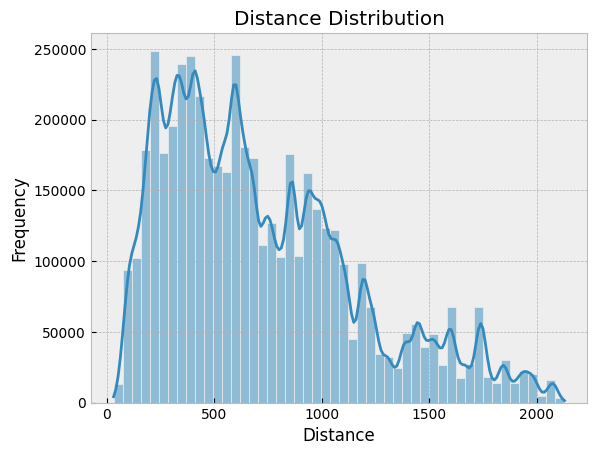

In [42]:
sns.histplot(df["DISTANCE"], bins=50, kde=True)
plt.title("Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()

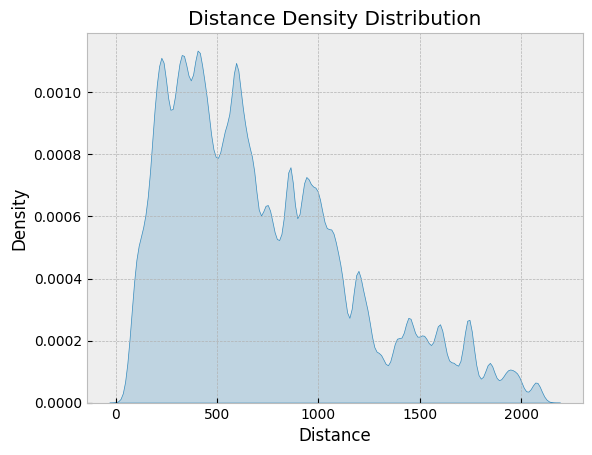

In [43]:
sns.kdeplot(df["DISTANCE"], fill=True)
plt.title("Distance Density Distribution")
plt.xlabel("Distance")
plt.ylabel("Density")
plt.show()

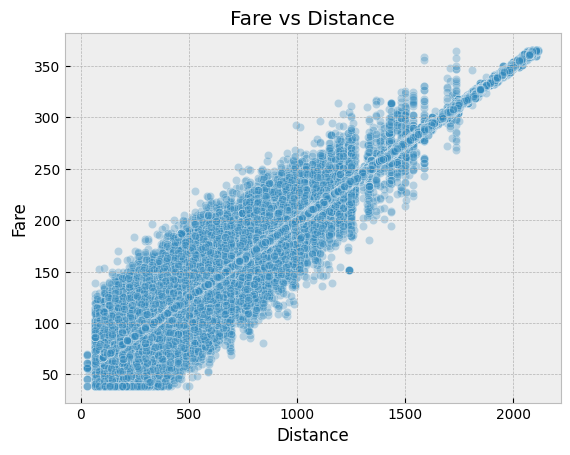

In [44]:
sample_df = df.sample(n=200000, random_state=42)
sns.scatterplot(x="DISTANCE", y="FARE", data=sample_df, alpha=0.3)
plt.title("Fare vs Distance")
plt.xlabel("Distance")
plt.ylabel("Fare")
plt.show()

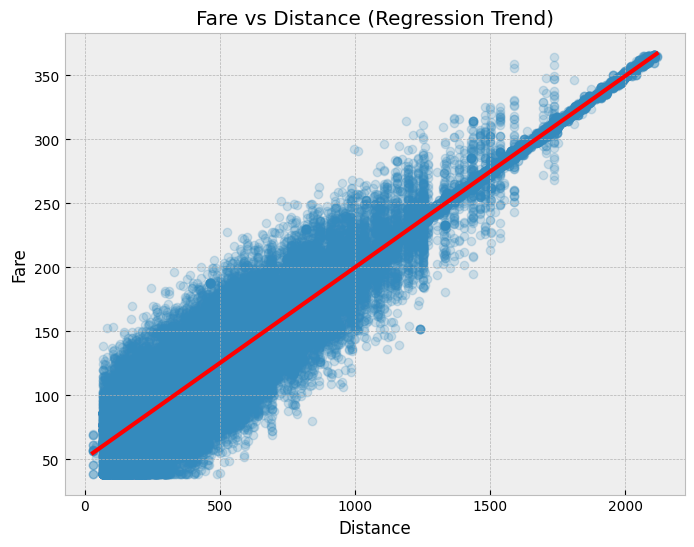

In [45]:
plt.figure(figsize=(8,6))

sns.regplot(
    x="DISTANCE",
    y="FARE",
    data=sample_df,
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title("Fare vs Distance (Regression Trend)")
plt.xlabel("Distance")
plt.ylabel("Fare")

plt.show()

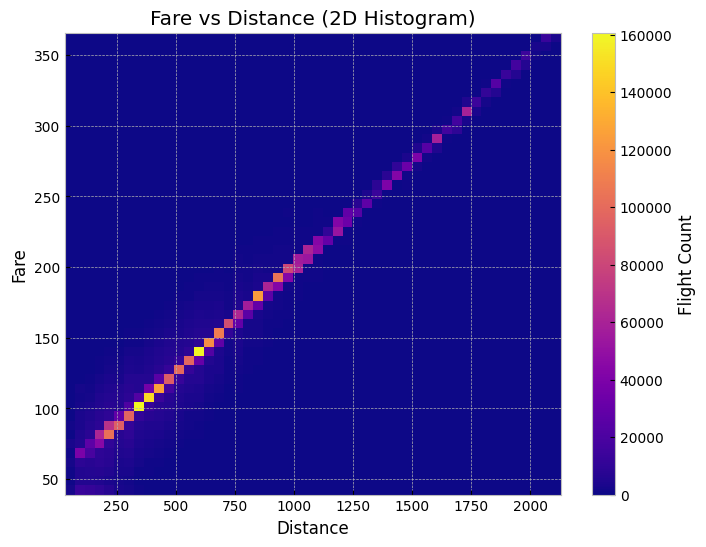

In [46]:
plt.figure(figsize=(8,6))

plt.hist2d(
    df["DISTANCE"],
    df["FARE"],
    bins=50,
    cmap="plasma"
)

plt.colorbar(label="Flight Count")

plt.xlabel("Distance")
plt.ylabel("Fare")
plt.title("Fare vs Distance (2D Histogram)")

plt.show()

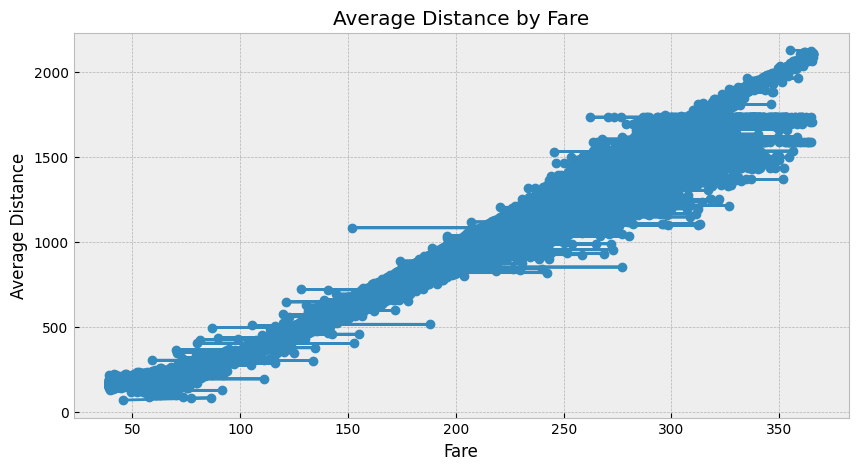

In [47]:
relation_flight = df.groupby('FARE')['DISTANCE'].mean().sort_values()
relation_flight.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Average Distance by Fare')
plt.xlabel('Fare')
plt.ylabel('Average Distance')
plt.show()

C:\Users\adilp\AppData\Local\Temp\ipykernel_25260\2919334985.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  relation = df.groupby('FARE_BIN')['DISTANCE'].mean()


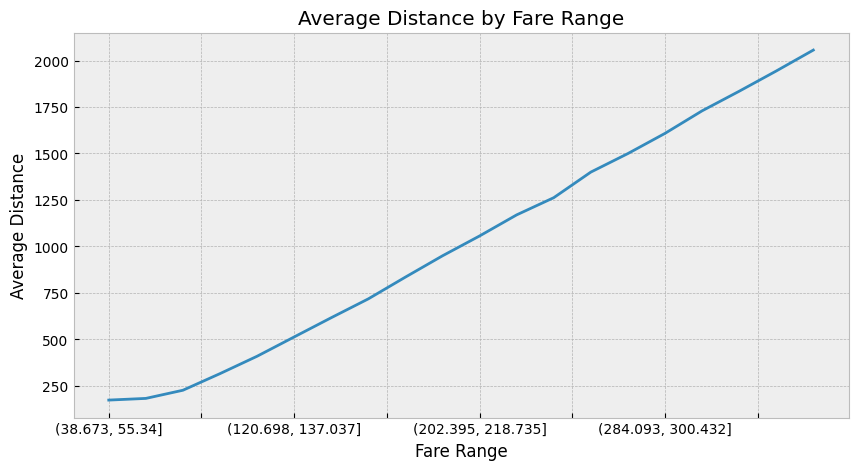

In [48]:
df['FARE_BIN'] = pd.cut(df['FARE'], bins=20)

relation = df.groupby('FARE_BIN')['DISTANCE'].mean()

relation.plot(figsize=(10,5))
plt.title("Average Distance by Fare Range")
plt.xlabel("Fare Range")
plt.ylabel("Average Distance")
plt.show()

In [49]:
df.head()

,MONTH,DAY,DAY_OF_WEEK,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_TIME,DISTANCE,FARE,AIRLINE,DEP_HOUR,ARR_HOUR,DEP_MIN,ARR_MIN,IS_WEEKEND,ROUTE,DEP_TIME_BIN,IS_HOLIDAY_SEASON,FARE_PER_MILE,FARE_BIN
0,1,1,4,ANC,SEA,205.0,1448,266.42,Alaska Airlines Inc.,0,4,5,30,0,ANC_SEA,Early_Morning,0,0.183992,"(251.414, 267.753]"
1,1,1,4,SEA,ANC,235.0,1448,267.21,Alaska Airlines Inc.,0,3,25,20,0,SEA_ANC,Early_Morning,0,0.184537,"(251.414, 267.753]"
2,1,1,4,SFO,MSP,217.0,1589,288.16,Delta Air Lines Inc.,0,6,25,2,0,SFO_MSP,Early_Morning,0,0.181347,"(284.093, 300.432]"
3,1,1,4,LAS,MSP,181.0,1299,247.22,Spirit Air Lines,0,5,25,26,0,LAS_MSP,Early_Morning,0,0.190316,"(235.074, 251.414]"
4,1,1,4,SFO,DFW,195.0,1464,269.36,American Airlines Inc.,0,5,30,45,0,SFO_DFW,Early_Morning,0,0.183989,"(267.753, 284.093]"


SCHEDULED TIME

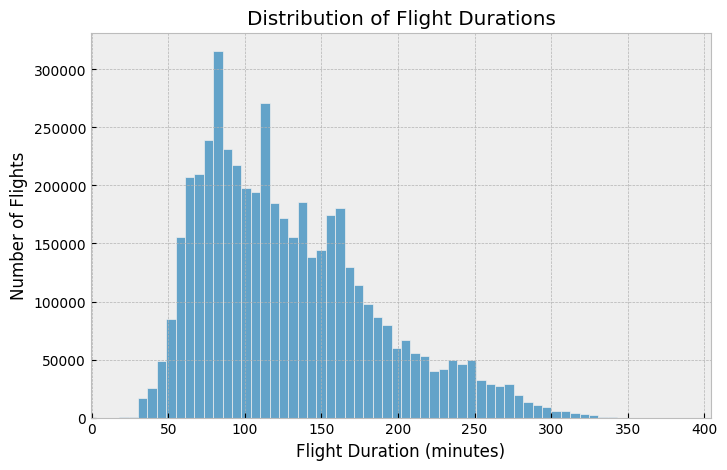

In [50]:
plt.figure(figsize=(8,5))

sns.histplot(df["SCHEDULED_TIME"], bins=60)

plt.title("Distribution of Flight Durations")
plt.xlabel("Flight Duration (minutes)")
plt.ylabel("Number of Flights")

plt.show()

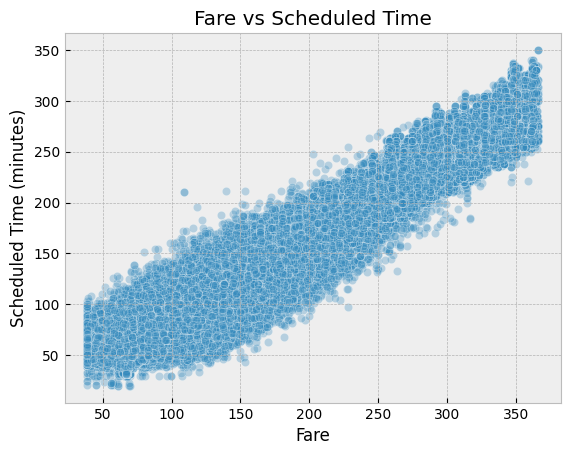

In [51]:
sample_df = df.sample(n=200000, random_state=42)
sns.scatterplot(x = 'FARE', y = 'SCHEDULED_TIME', data=sample_df, alpha=0.3)
plt.title("Fare vs Scheduled Time")
plt.xlabel("Fare")
plt.ylabel("Scheduled Time (minutes)")
plt.show()

In [52]:
df["SCHEDULED_TIME"].corr(df["DISTANCE"])

np.float64(0.9781882660052054)

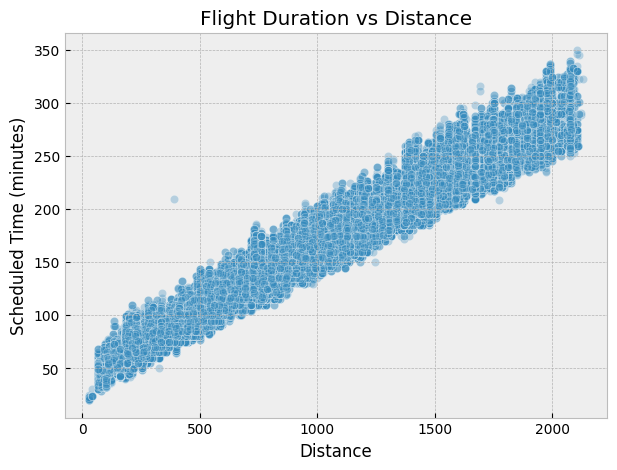

In [53]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="DISTANCE",
    y="SCHEDULED_TIME",
    data=df.sample(200000),
    alpha=0.3
)

plt.title("Flight Duration vs Distance")
plt.xlabel("Distance")
plt.ylabel("Scheduled Time (minutes)")

plt.show()

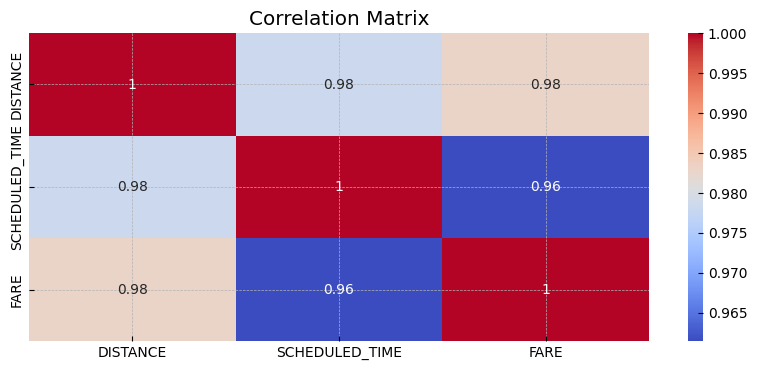

In [54]:
plt.figure(figsize=(10,4))

sns.heatmap(
    df[["DISTANCE","SCHEDULED_TIME","FARE"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [55]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_TIME,DISTANCE,FARE,DEP_HOUR,ARR_HOUR,DEP_MIN,ARR_MIN,IS_WEEKEND,IS_HOLIDAY_SEASON,FARE_PER_MILE
MONTH,1.000000,0.003331,-0.014067,0.010383,0.009830,0.009818,0.000289,-0.010700,0.000409,0.006245,-0.000090,0.610633,-0.008311
DAY,0.003331,1.000000,0.005022,0.002681,0.003011,0.002926,-0.001478,-0.003701,0.000473,0.001052,0.012246,0.001574,-0.001902
DAY_OF_WEEK,-0.014067,0.005022,1.000000,0.013359,0.014943,0.014789,0.007771,0.007839,0.001245,0.000506,0.781355,-0.015811,-0.006064
SCHEDULED_TIME,0.010383,0.002681,0.013359,1.000000,0.978188,0.961435,-0.049562,0.043932,0.012202,0.002487,0.018156,0.012659,-0.612588
DISTANCE,0.009830,0.003011,0.014943,0.978188,1.000000,0.982926,-0.045254,0.046498,0.014098,0.003960,0.020514,0.012037,-0.613598
FARE,0.009818,0.002926,0.014789,0.961435,0.982926,1.000000,-0.044671,0.045463,0.013768,0.003839,0.020261,0.012043,-0.536642
DEP_HOUR,0.000289,-0.001478,0.007771,-0.049562,-0.045254,-0.044671,1.000000,0.774266,0.046806,0.021601,0.002495,0.001829,0.029438
ARR_HOUR,-0.010700,-0.003701,0.007839,0.043932,0.046498,0.045463,0.774266,1.000000,0.079009,-0.015920,0.005149,-0.011590,-0.044972
DEP_MIN,0.000409,0.000473,0.001245,0.012202,0.014098,0.013768,0.046806,0.079009,1.000000,0.012710,0.000846,0.001231,-0.002223
ARR_MIN,0.006245,0.001052,0.000506,0.002487,0.003960,0.003839,0.021601,-0.015920,0.012710,1.000000,0.000206,0.001785,0.002504


In [56]:
df["DISTANCE"].corr(df["SCHEDULED_TIME"])

np.float64(0.9781882660052054)

In [57]:
fare_corr = df.corr(numeric_only=True)["FARE"].sort_values(ascending=False)
fare_corr

FARE                 1.000000
DISTANCE             0.982926
SCHEDULED_TIME       0.961435
ARR_HOUR             0.045463
IS_WEEKEND           0.020261
DAY_OF_WEEK          0.014789
DEP_MIN              0.013768
IS_HOLIDAY_SEASON    0.012043
MONTH                0.009818
ARR_MIN              0.003839
DAY                  0.002926
DEP_HOUR            -0.044671
FARE_PER_MILE       -0.536642
Name: FARE, dtype: float64

MULTI VARIABLE ANALYSIS

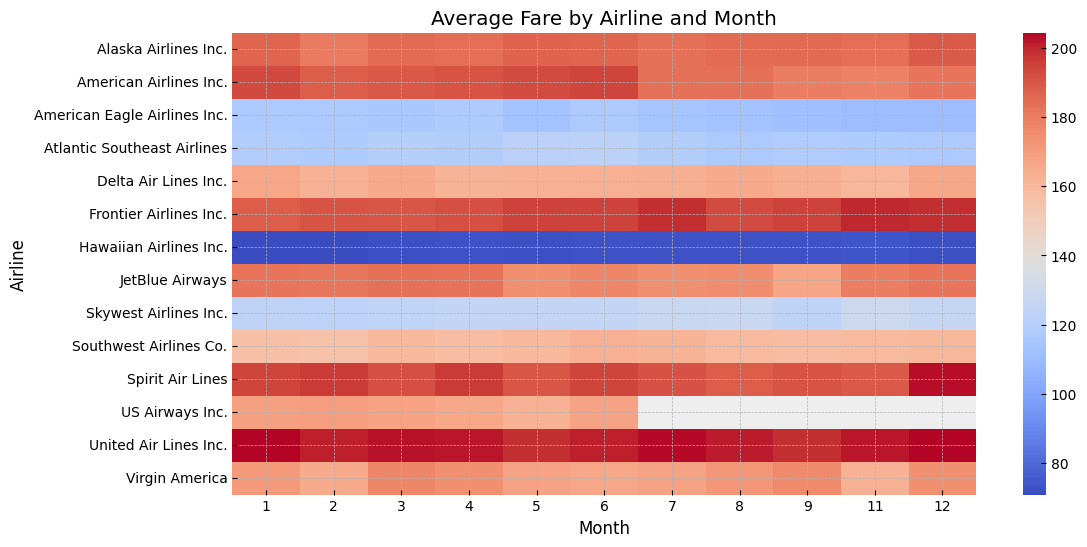

In [58]:
pivot = sample_df.pivot_table(
    values="FARE",
    index="AIRLINE",
    columns="MONTH",
    aggfunc="mean"
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    cmap="coolwarm",
    annot=False
)

plt.title("Average Fare by Airline and Month")
plt.xlabel("Month")
plt.ylabel("Airline")

plt.show()

In [59]:
df.head()

,MONTH,DAY,DAY_OF_WEEK,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_TIME,DISTANCE,FARE,AIRLINE,DEP_HOUR,ARR_HOUR,DEP_MIN,ARR_MIN,IS_WEEKEND,ROUTE,DEP_TIME_BIN,IS_HOLIDAY_SEASON,FARE_PER_MILE,FARE_BIN
0,1,1,4,ANC,SEA,205.0,1448,266.42,Alaska Airlines Inc.,0,4,5,30,0,ANC_SEA,Early_Morning,0,0.183992,"(251.414, 267.753]"
1,1,1,4,SEA,ANC,235.0,1448,267.21,Alaska Airlines Inc.,0,3,25,20,0,SEA_ANC,Early_Morning,0,0.184537,"(251.414, 267.753]"
2,1,1,4,SFO,MSP,217.0,1589,288.16,Delta Air Lines Inc.,0,6,25,2,0,SFO_MSP,Early_Morning,0,0.181347,"(284.093, 300.432]"
3,1,1,4,LAS,MSP,181.0,1299,247.22,Spirit Air Lines,0,5,25,26,0,LAS_MSP,Early_Morning,0,0.190316,"(235.074, 251.414]"
4,1,1,4,SFO,DFW,195.0,1464,269.36,American Airlines Inc.,0,5,30,45,0,SFO_DFW,Early_Morning,0,0.183989,"(267.753, 284.093]"


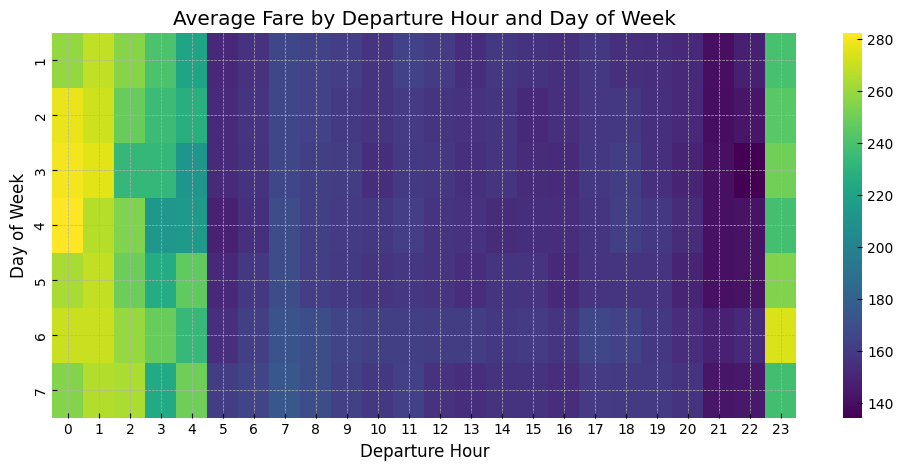

In [60]:
pivot = sample_df.pivot_table(
    values="FARE",
    index="DAY_OF_WEEK",
    columns="DEP_HOUR",
    aggfunc="mean"
)

plt.figure(figsize=(12,5))

sns.heatmap(
    pivot,
    cmap="viridis"
)

plt.title("Average Fare by Departure Hour and Day of Week")
plt.xlabel("Departure Hour")
plt.ylabel("Day of Week")

plt.show()

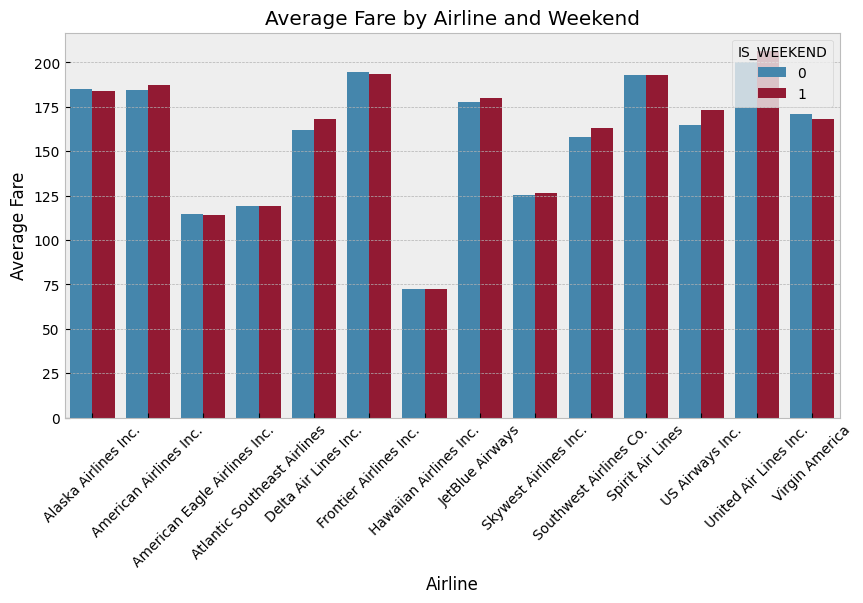

In [61]:
sample_df = df.sample(n=200000, random_state=42)
avg_fare = sample_df.groupby(
    ["AIRLINE","IS_WEEKEND"]
)["FARE"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.barplot(
    data=avg_fare,
    x="AIRLINE",
    y="FARE",
    hue="IS_WEEKEND"
)

plt.xticks(rotation=45)

plt.title("Average Fare by Airline and Weekend")
plt.xlabel("Airline")
plt.ylabel("Average Fare")

plt.show()

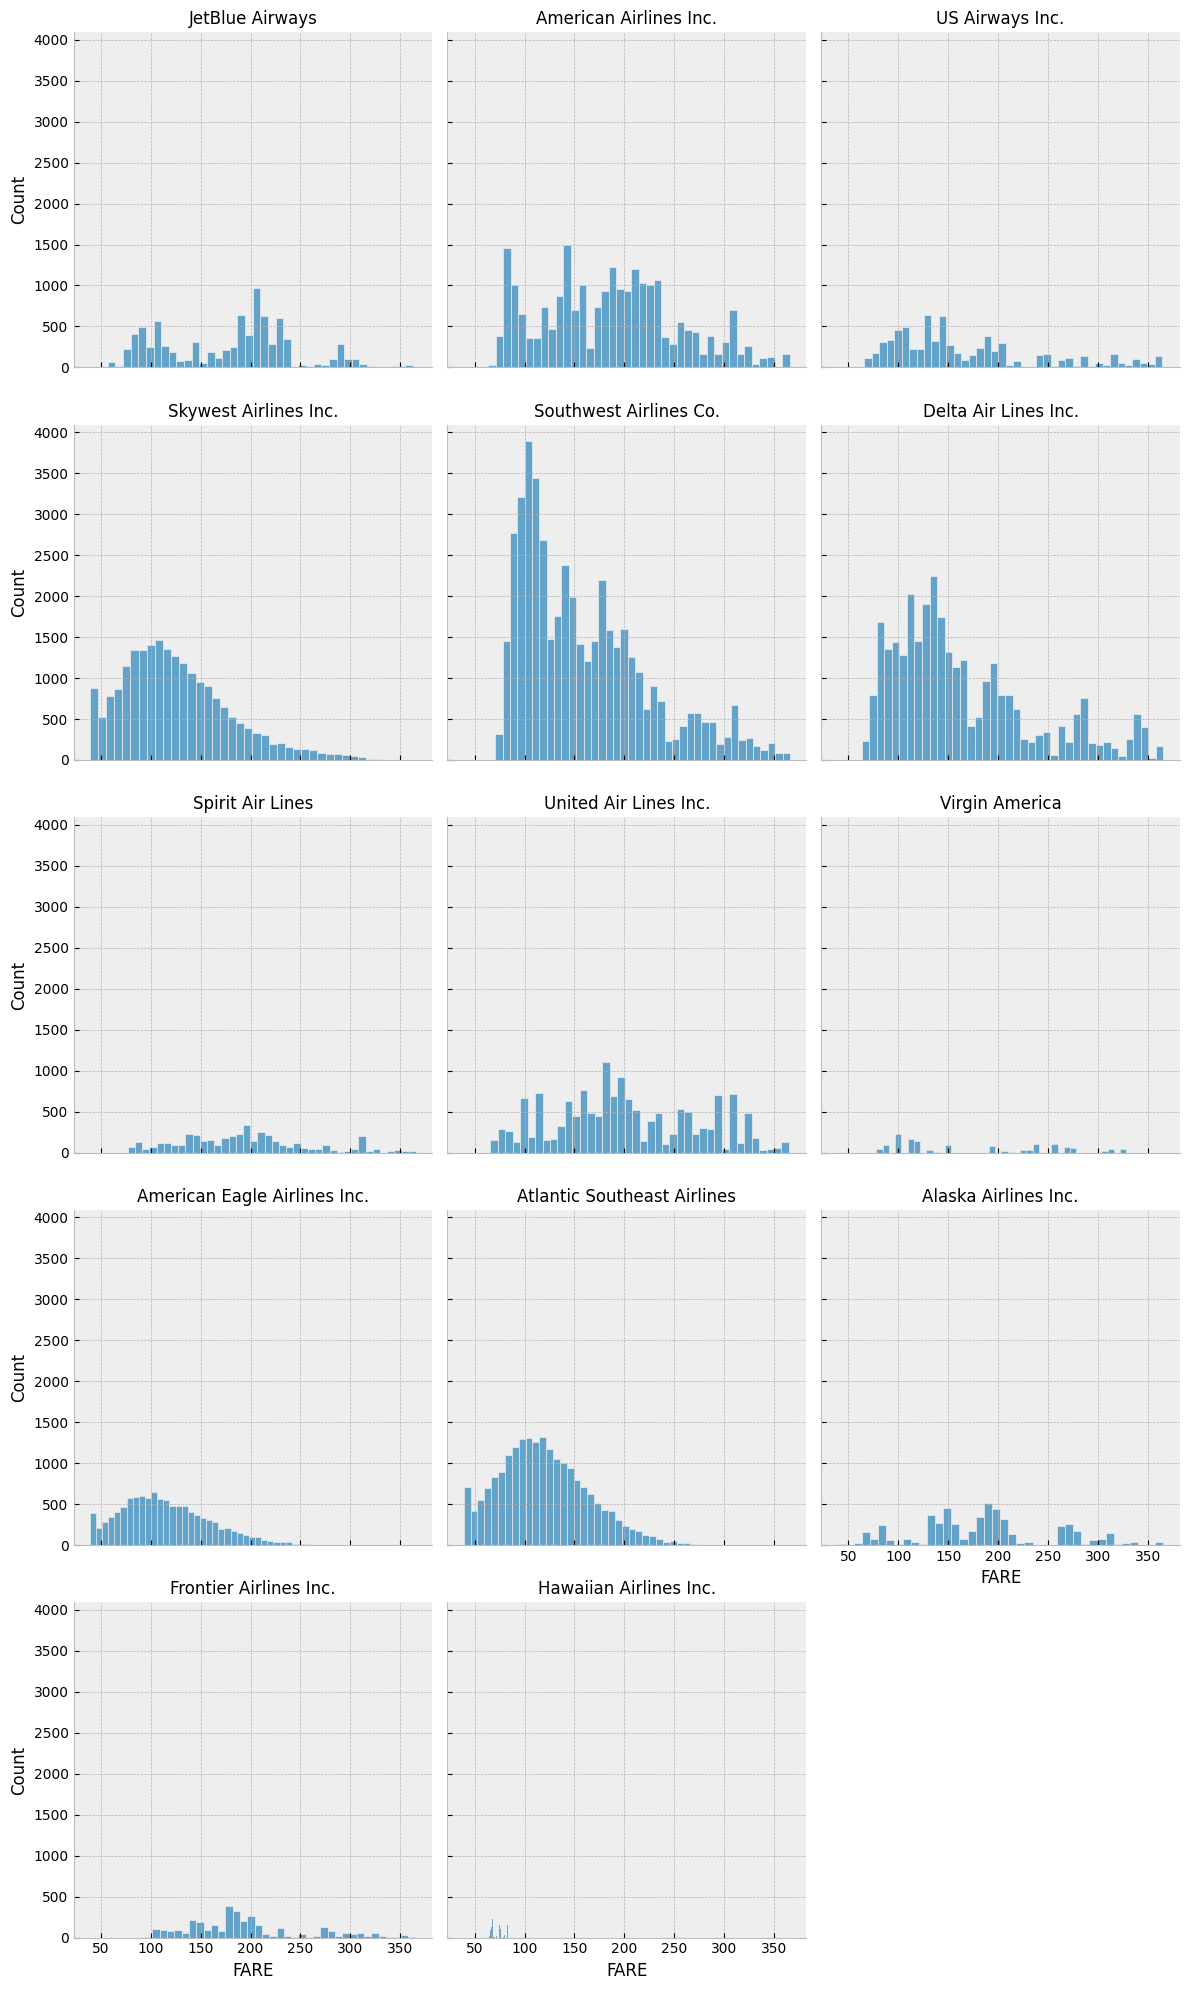

In [62]:
g = sns.FacetGrid(
    sample_df,
    col="AIRLINE",
    col_wrap=3,
    height=4
)

g.map_dataframe(
    sns.histplot,
    x="FARE",
    bins=40
)

g.set_titles("{col_name}")
plt.show()

In [63]:
df['FARE'].describe()

count    4.916353e+06
mean     1.581386e+02
std      6.857421e+01
min      3.900000e+01
25%      1.047900e+02
50%      1.443000e+02
75%      1.986500e+02
max      3.657900e+02
Name: FARE, dtype: float64